# Experiment 4 — RECOVERY (Resume from crash)
Skips completed models, finishes the rest fast.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import time
import gc
import os

RESULTS_CSV = "images/comparison_table.csv"

# Reload data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

# Check what's done
df_done = pd.read_csv(RESULTS_CSV)
completed_models = df_done['Model'].unique()
print("Already completed:")
for m in completed_models:
    print(f"  ✓ {m}")

Already completed:
  ✓ LeNet-5
  ✓ AlexNet
  ✓ GoogleNet
  ✓ VGG16


In [7]:
# Setup (copy from Untitled3)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.makedirs("images", exist_ok=True)

def make_bold_ticks(ax):
    for label in ax.get_xticklabels(): label.set_fontweight("bold")
    for label in ax.get_yticklabels(): label.set_fontweight("bold")

def save_figure(name):
    make_bold_ticks(plt.gca())
    plt.savefig(f"images/{name}.eps", format="eps", dpi=300, bbox_inches="tight")
    plt.show()

def append_result_row(row):
    df_row = pd.DataFrame([row])
    if os.path.exists(RESULTS_CSV):
        df_row.to_csv(RESULTS_CSV, mode='a', header=False, index=False)
    else:
        df_row.to_csv(RESULTS_CSV, mode='w', header=True, index=False)
    print(f"✓ Checkpointed: {row['Model']}")

def build_tf_dataset(x, y, img_size, preprocess_fn, batch_size=32, training=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    def _map(img, label):
        if img_size != 32:
            img = tf.image.resize(img, (img_size, img_size))
        if preprocess_fn is not None:
            img = preprocess_fn(img * 255.0)
        label = tf.one_hot(label, 10)
        return img, label
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=SEED)
    ds = ds.cache()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def train_and_time(model, train_ds, val_ds, epochs, model_name):
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start
    print(f"[{model_name}] Time: {elapsed/60:.2f} min")
    return history, elapsed

def evaluate_model(model, test_ds, y_true, model_name):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{model_name} → Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.xlabel('Predicted', fontweight='bold')
    plt.ylabel('Actual', fontweight='bold')
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    save_figure(f"confusion_matrix_{model_name.lower().replace(' ', '_')}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}

def plot_training_curves(history_dict, model_name, fine_tune_epoch=None):
    epochs_range = range(len(history_dict['accuracy']))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, history_dict['accuracy'], label='Training', linewidth=2)
    ax1.plot(epochs_range, history_dict['val_accuracy'], label='Validation', linewidth=2)
    if fine_tune_epoch:
        ax1.axvline(x=fine_tune_epoch, color='red', linestyle='--', alpha=0.7)
    ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Accuracy', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(epochs_range, history_dict['loss'], label='Training', linewidth=2)
    ax2.plot(epochs_range, history_dict['val_loss'], label='Validation', linewidth=2)
    if fine_tune_epoch:
        ax2.axvline(x=fine_tune_epoch, color='red', linestyle='--', alpha=0.7)
    ax2.set_title(f'{model_name} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure(f"curves_{model_name.lower().replace(' ', '_')}")

def free_memory(*objs):
    for o in objs:
        del o
    tf.keras.backend.clear_session()
    gc.collect()

print("✓ Setup complete")

✓ Setup complete


In [8]:
# ============================================================================
# TRANSFER LEARNING FUNCTION
# ============================================================================
def build_transfer_model(base_class, img_size, dense_units=256):
    base = base_class(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x)
    return models.Model(inputs, outputs), base

def run_transfer_pipeline(base_class, preprocess_fn, img_size, model_name,
                          frozen_epochs=6, fine_tune_epochs=4, unfreeze_fraction=0.2):
    """FAST transfer learning."""
    train_ds = build_tf_dataset(x_train, y_train, img_size, preprocess_fn, batch_size=32, training=True)
    test_ds  = build_tf_dataset(x_test, y_test, img_size, preprocess_fn, batch_size=32, training=False)

    model, base = build_transfer_model(base_class, img_size)
    model.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"\n{'='*60}\n{model_name} — Frozen Base ({frozen_epochs} epochs)\n{'='*60}")
    hist1, t1 = train_and_time(model, train_ds, test_ds, frozen_epochs, f"{model_name} (frozen)")

    base.trainable = True
    n_layers = len(base.layers)
    freeze_until = int(n_layers * (1 - unfreeze_fraction))
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    print(f"Unfroze {n_layers - freeze_until}/{n_layers} layers")

    model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"\n{'='*60}\n{model_name} — Fine-Tuning ({fine_tune_epochs} epochs)\n{'='*60}")
    hist2, t2 = train_and_time(model, train_ds, test_ds, fine_tune_epochs, f"{model_name} (fine-tune)")

    merged = {k: hist1.history[k] + hist2.history[k] for k in hist1.history}
    plot_training_curves(merged, model_name, fine_tune_epoch=frozen_epochs)
    metrics = evaluate_model(model, test_ds, y_test, model_name)
    total_time = t1 + t2
    append_result_row({"Model": model_name, "Parameters": model.count_params(),
                        "Accuracy (%)": round(metrics["accuracy"]*100, 2),
                        "Training Time (min)": round(total_time/60, 2)})
    free_memory(model, train_ds, test_ds)
    return metrics, merged, total_time

IMG_SIZE_PRETRAINED = 96
print("✓ Transfer learning ready")

✓ Transfer learning ready


In [9]:
import os
import shutil

# Delete cache
if os.path.exists('/tmp/cache'):
    shutil.rmtree('/tmp/cache')
    print("✓ Cleared /tmp/cache")

# Delete old notebooks/backups
for f in os.listdir('.'):
    if f.startswith('.ipynb_checkpoints') or f.endswith('.tmp'):
        shutil.rmtree(f) if os.path.isdir(f) else os.remove(f)
        print(f"✓ Deleted {f}")

print("Disk cleaned!")

✓ Deleted .ipynb_checkpoints
Disk cleaned!



############################################################
# ResNet50 TRANSFER LEARNING
############################################################

ResNet50 — Frozen Base (6 epochs)
Epoch 1/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1498s 946ms/step - accuracy: 0.7603 - loss: 0.7566 - val_accuracy: 0.8337 - val_loss: 0.4605
Epoch 2/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1569s 1s/step - accuracy: 0.8425 - loss: 0.4560 - val_accuracy: 0.8549 - val_loss: 0.4300
Epoch 3/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1472s 941ms/step - accuracy: 0.8629 - loss: 0.4000 - val_accuracy: 0.8565 - val_loss: 0.4417
Epoch 4/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1486s 918ms/step - accuracy: 0.8720 - loss: 0.3605 - val_accuracy: 0.8560 - val_loss: 0.4451
Epoch 5/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1411s 902ms/step - accuracy: 0.8858 - loss: 0.3267 - val_accuracy: 0.8540 - val_loss: 0.4653
Epoch 6/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1392s 891ms/step - accuracy: 0.8944 - loss: 0.3031 - val_accuracy: 0.8600 - val_loss: 0.4439
[ResNet50 (f

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


OSError: [Errno 28] No space left on device

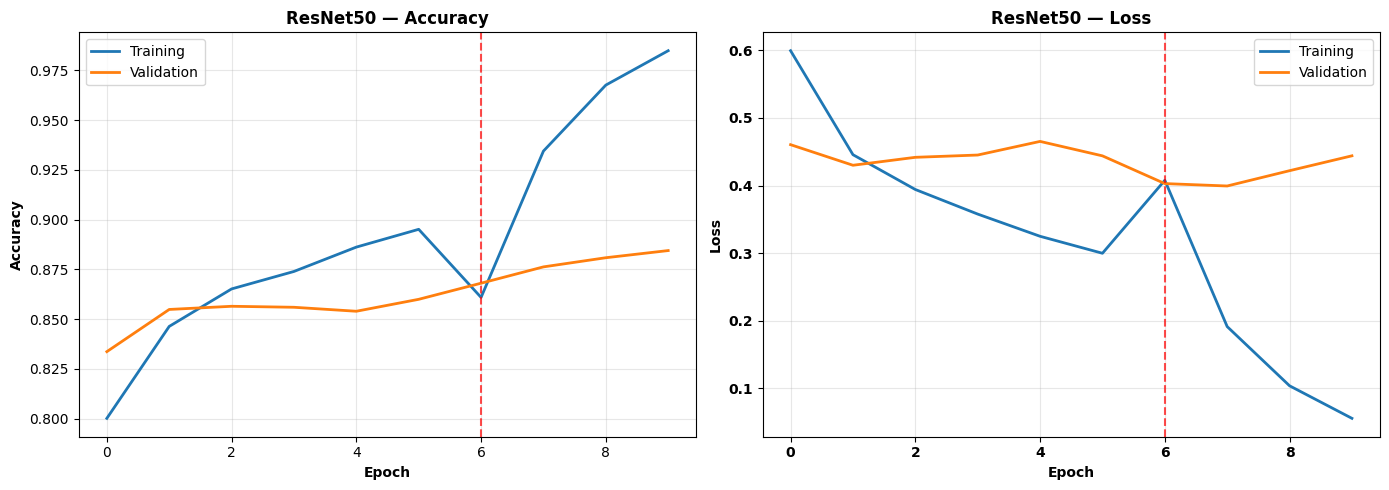

In [10]:
# ============================================================================
# RUN MISSING MODELS (ResNet50, InceptionV3)
# ============================================================================

if 'ResNet50' not in completed_models:
    print("\n" + "#"*60)
    print("# ResNet50 TRANSFER LEARNING")
    print("#"*60)
    resnet_metrics, resnet_history, resnet_time = run_transfer_pipeline(
        ResNet50, resnet_preprocess, IMG_SIZE_PRETRAINED, "ResNet50",
        frozen_epochs=6, fine_tune_epochs=4
    )
else:
    print("✓ ResNet50 already done")

if 'InceptionV3' not in completed_models:
    print("\n" + "#"*60)
    print("# InceptionV3 TRANSFER LEARNING")
    print("#"*60)
    inception_metrics, inception_history, inception_time = run_transfer_pipeline(
        InceptionV3, inception_preprocess, IMG_SIZE_PRETRAINED, "InceptionV3",
        frozen_epochs=6, fine_tune_epochs=4
    )
else:
    print("✓ InceptionV3 already done")

In [ ]:
# ============================================================================
# FINAL RESULTS TABLE + PLOTS
# ============================================================================
print("\n" + "="*70)
print("FINAL RESULTS — ALL MODELS")
print("="*70)

# Clean up duplicate LeNet entries (keep only latest)
df_final = pd.read_csv(RESULTS_CSV)
df_final_clean = df_final.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)
df_final_clean.to_csv(RESULTS_CSV, index=False)

print("\n")
print(df_final_clean.to_string(index=False))

# Accuracy comparison
plt.figure(figsize=(12, 6))
colors = ['#1f77b4' if 'ResNet' in m or 'VGG' in m else '#ff7f0e' if 'Google' in m or 'Inception' in m else '#2ca02c' 
          for m in df_final_clean['Model']]
bars = plt.bar(df_final_clean['Model'], df_final_clean['Accuracy (%)'], color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
plt.title('All CNN Architectures — Test Accuracy', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.ylim([0, 100])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_figure('final_accuracy_comparison')

# Training time comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(df_final_clean['Model'], df_final_clean['Training Time (min)'], color='#d62728', edgecolor='black', linewidth=1.5)
plt.ylabel('Training Time (minutes)', fontweight='bold', fontsize=12)
plt.title('All CNN Architectures — Training Time', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}m', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_figure('final_training_time_comparison')

print("\n✅ Experiment 4 COMPLETE!")
print("="*70)

In [ ]:
# QUICK HP SWEEP (6 configs only - no caching for speed)
print("\n" + "#"*60)
print("# QUICK HYPERPARAMETER SWEEP")
print("#"*60)

def build_transfer_model_flexible(base_class, img_size, dense_units=256, frozen_mode='all'):
    base = base_class(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
    base.trainable = (frozen_mode == 'partial')
    if frozen_mode == 'partial':
        n_layers = len(base.layers)
        freeze_until = int(n_layers * 0.8)
        for layer in base.layers[:freeze_until]:
            layer.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=(frozen_mode == 'partial'))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x)
    return models.Model(inputs, outputs)

def run_hp_config(config):
    train_ds_hp = build_tf_dataset(x_train, y_train, IMG_SIZE_PRETRAINED, resnet_preprocess,
                                    batch_size=config['batch_size'], training=True)
    test_ds_hp = build_tf_dataset(x_test, y_test, IMG_SIZE_PRETRAINED, resnet_preprocess,
                                   batch_size=config['batch_size'], training=False)
    model_hp = build_transfer_model_flexible(ResNet50, IMG_SIZE_PRETRAINED,
                                              dense_units=config['dense_units'],
                                              frozen_mode=config['frozen_mode'])
    opt = optimizers.Adam(config['lr']) if config['optimizer'] == 'adam' else \
          optimizers.SGD(config['lr'], momentum=0.9)
    model_hp.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    hist_hp = model_hp.fit(train_ds_hp, validation_data=test_ds_hp, epochs=config['epochs'], verbose=0)
    elapsed = time.time() - start
    result = {**config, "Val Accuracy": round(hist_hp.history['val_accuracy'][-1], 4),
              "Time/Epoch (s)": round(elapsed/config['epochs'], 1)}
    free_memory(model_hp, train_ds_hp, test_ds_hp)
    return result

baseline = {"lr": 0.001, "batch_size": 32, "epochs": 3,
            "optimizer": "adam", "dense_units": 256, "frozen_mode": "all"}

hp_configs = []
for lr in [0.001, 0.0001]:
    cfg = baseline.copy()
    cfg["lr"] = lr
    cfg["varied_param"] = "lr"
    hp_configs.append(cfg)
for bs in [32, 64]:
    cfg = baseline.copy()
    cfg["batch_size"] = bs
    cfg["varied_param"] = "batch_size"
    hp_configs.append(cfg)
for fm in ["all", "partial"]:
    cfg = baseline.copy()
    cfg["frozen_mode"] = fm
    cfg["varied_param"] = "frozen_mode"
    hp_configs.append(cfg)

print(f"Running {len(hp_configs)} configs (3 epochs each)...\n")
hp_results = []
for i, cfg in enumerate(hp_configs, 1):
    result = run_hp_config(cfg)
    hp_results.append(result)
    print(f"[{i}/{len(hp_configs)}] {cfg['varied_param']}={cfg[cfg['varied_param']]} → {result['Val Accuracy']:.4f}")

df_hp = pd.DataFrame(hp_results)
df_hp.to_csv("images/hyperparameter_study.csv", index=False)
print("\n✓ HP sweep complete")

In [ ]:
# HP Sensitivity plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
params = {"lr": "Learning Rate", "batch_size": "Batch Size", "frozen_mode": "Frozen Mode"}
for ax, (param, label) in zip(axes, params.items()):
    subset = df_hp[df_hp["varied_param"] == param]
    vals = subset[param].astype(str)
    accs = subset["Val Accuracy"]
    bars = ax.bar(range(len(vals)), accs, color="#4C72B0", edgecolor='black')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals, fontweight='bold')
    ax.set_ylabel('Val Accuracy', fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.suptitle('Hyperparameter Sensitivity Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
save_figure('hp_sensitivity')

print("\n" + "="*70)
print("✅✅✅ EXPERIMENT 4 — ALL DONE ✅✅✅")
print("="*70)